## CHECK WHICH ONE IS 0xVF AND 2xVF

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import os
import glob

In [4]:
# Path leading to _processedData folders
# data_alingned_path = '/mnt/disk2/Arthur_data/B6J3217-2025-07-02T13-13-14_processedData/aligned_data/B6J3217_downsampled_data_Apply halt: 2s_aligned.csv'
# Define the root path
# work for multiple paths to process
paths_to_process = {
    'processed_data_path_2xVF' : 'C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3',
    'processed_data_path_0xVF' : 'C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day4'
}   

# paths_to_process = {
#     'processed_data_path_0xVF' : '/mnt/disk2/Arthur_data/Visual_mismatch_day3',
#     'processed_data_path_2xVF' : '/mnt/disk2/Arthur_data/Visual_mismatch_day4'
# }  

data_aligned_dict_MM = {key: {} for key in paths_to_process.keys()}

for key, processed_data_path in paths_to_process.items():
    # Find all folders ending with '_processedData'
    processed_folders = glob.glob(os.path.join(processed_data_path, '*_processedData'))
    
    # For each processed folder, look for 'aligned_data' subfolder
    i = 0
    for folder in processed_folders:
        aligned_data_path = os.path.join(folder, 'aligned_data')

        # Check if 'aligned_data' exists and find matching files
        if os.path.exists(aligned_data_path):
            matching_files = glob.glob(os.path.join(aligned_data_path, '*_downsampled_data_Apply halt_2s_aligned.csv'))

            # Print or process the matching files
            for file in matching_files:
                print(f"Found file: {file}")
                # Read the CSV file into a DataFrame
                df = pd.read_csv(file)
                # Store the DataFrame in the dictionary with a dynamic key
                data_aligned_dict_MM[key][f"data_aligned_csv_{i}"] = df
                i += 1

        else:
            print(f"Folder not found: {aligned_data_path}")

# baseline everything cf BASELINE_WINDOWS_SUMMARY
for key in data_aligned_dict_MM.keys():
    for df_key, df in data_aligned_dict_MM[key].items():

        # Creation of new column with index of each MM
        halt_index = 0
        halt_indices = []
        prev_halt_time = None

        for _, row in df.iterrows():
            if row['Halt Time'] != prev_halt_time:
                halt_index += 1
                prev_halt_time = row['Halt Time']
            halt_indices.append(halt_index-1)

        df['halt_index'] = halt_indices

        bin_indices = []

        for _, row in df.iterrows():
            th_time = 10
            for i in range(8):
                if row['Time (s)'] <= th_time:
                    bin_index = 7-i
                    th_time -=2
            
            bin_indices.append(bin_index)

        df['bin_index'] = bin_indices

        # Printing every column names to see every variables
        print(f"Columns in {key} ({df_key}): {df.columns}")


Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2718-2024-12-10T12-57-02_processedData\aligned_data\B6J2718_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2719-2024-12-10T13-36-31_processedData\aligned_data\B6J2719_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2721-2024-12-10T14-18-54_processedData\aligned_data\B6J2721_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2722-2024-12-10T14-58-52_processedData\aligned_data\B6J2722_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2723-2024-12-10T15-36-13_processedData\aligned_data\B6J2723_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day4\B6J2718-

In [3]:
data_aligned_dict_MM

{'processed_data_path_0xVF': {'data_aligned_csv_0':          Encoder  Position_0X  Position_0Y  CumulativeCounts_0X  \
  0       248.8522       4.4933   -3254.8013             566098.0   
  1       248.8578       4.4933   -3254.8635             566098.0   
  2       248.8634       4.4933   -3254.9263             566098.0   
  3       248.8690       4.4933   -3254.9904             566098.0   
  4       248.8746       4.4933   -3255.0563             566098.0   
  ...          ...          ...          ...                  ...   
  464024  248.0150      58.1057  -16319.2333            7320542.0   
  464025  248.0203      58.1057  -16319.2927            7320542.0   
  464026  248.0256      58.1058  -16319.3502            7320542.0   
  464027  248.0308      58.1059  -16319.4063            7320542.0   
  464028  248.0360      58.1060  -16319.4615            7320542.0   
  
          CumulativeCounts_0Y  dfF_470  dfF_560  dfF_410   z_470   z_560  ...  \
  0                 -715829.0  -0.0083

In [5]:
data_aligned_dict_no_MM = {key: {} for key in paths_to_process.keys()}

for key, processed_data_path in paths_to_process.items():
    # Find all folders ending with '_processedData'
    processed_folders = glob.glob(os.path.join(processed_data_path, '*_processedData'))
    
    # For each processed folder, look for 'aligned_data' subfolder
    i = 0
    for folder in processed_folders:
        aligned_data_path = os.path.join(folder, 'aligned_data')

        # Check if 'aligned_data' exists and find matching files
        if os.path.exists(aligned_data_path):
            matching_files = glob.glob(os.path.join(aligned_data_path, '*_downsampled_data_No halt_aligned.csv'))

            # Print or process the matching files
            for file in matching_files:
                print(f"Found file: {file}")
                # Read the CSV file into a DataFrame
                df = pd.read_csv(file)
                # Store the DataFrame in the dictionary with a dynamic key
                data_aligned_dict_no_MM[key][f"data_aligned_csv_{i}"] = df
                i += 1

        else:
            print(f"Folder not found: {aligned_data_path}")

# baseline everything cf BASELINE_WINDOWS_SUMMARY
for key in data_aligned_dict_no_MM.keys():
    for df_key, df in data_aligned_dict_no_MM[key].items():

        # Creation of new column with index of each MM
        halt_index = 0
        halt_indices = []
        prev_halt_time = None

        for _, row in df.iterrows():
            if row['Halt Time'] != prev_halt_time:
                halt_index += 1
                prev_halt_time = row['Halt Time']
            halt_indices.append(halt_index-1)

        df['halt_index'] = halt_indices

        bin_indices = []

        for _, row in df.iterrows():
            th_time = 10
            for i in range(8):
                if row['Time (s)'] <= th_time:
                    bin_index = 7-i
                    th_time -=2
            
            bin_indices.append(bin_index)

        df['bin_index'] = bin_indices

        # Printing every column names to see every variables
        print(f"Columns in {key} ({df_key}): {df.columns}")

Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2718-2024-12-10T12-57-02_processedData\aligned_data\B6J2718_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2719-2024-12-10T13-36-31_processedData\aligned_data\B6J2719_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2721-2024-12-10T14-18-54_processedData\aligned_data\B6J2721_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2722-2024-12-10T14-58-52_processedData\aligned_data\B6J2722_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2723-2024-12-10T15-36-13_processedData\aligned_data\B6J2723_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day4\B6J2718-2024-12-11T13-49-13_processedD

In [23]:
data_aligned_dict_no_MM

{'processed_data_path_0xVF': {'data_aligned_csv_0':          Encoder  Position_0X  Position_0Y  CumulativeCounts_0X  \
  0        16.8892       0.9925    -453.1572             125076.0   
  1        16.8955       0.9925    -453.2597             125076.0   
  2        16.9018       0.9926    -453.3601             125076.0   
  3        16.9081       0.9926    -453.4580             125076.0   
  4        16.9144       0.9926    -453.5543             125076.0   
  ...          ...          ...          ...                  ...   
  720040  316.3924      58.9187  -17116.0677            7422818.0   
  720041  316.3924      58.9186  -17116.0664            7422818.0   
  720042  316.3924      58.9186  -17116.0651            7422818.0   
  720043  316.3923      58.9186  -17116.0638            7422818.0   
  720044  316.3923      58.9186  -17116.0624            7422818.0   
  
          CumulativeCounts_0Y  dfF_470  dfF_560  dfF_410   z_470   z_560  ...  \
  0                  -99965.0  -0.0050

## Getting data for all MM across the session

## Dict for ratio change and delta before after MM

In [6]:
dict_ratios_MM = {key: {} for key in data_aligned_dict_MM.keys()}
dict_delta_MM = {key: {} for key in data_aligned_dict_MM.keys()}

for key in data_aligned_dict_MM.keys():
    print(f"Processing {key}...")
    dict_ratios_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_MM[key].items()}
    dict_delta_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_MM[key].items()}
    
    for df_key, df in data_aligned_dict_MM[key].items():
        print('\n')
        print(f"Processing {df_key}...")

        dict_changes_turning_speed = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_running_speed = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_activ = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_X = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_Y = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_pupil_diam = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_motor_velocity = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}

        dict_turning_speed_delta = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_running_speed_delta = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_activ_delta = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_ellipse_X_delta = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_ellipse_Y_delta = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_pupil_diam_delta = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_motor_velocity = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}


        for i in range(np.max(data_aligned_dict_MM[key][df_key]['halt_index'])+1):

            spe_halt_data = data_aligned_dict_MM[key][df_key].loc[data_aligned_dict_MM[key][df_key]['halt_index'] == i]

            spe_halt_bin_before_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 2]
            spe_halt_bin_after_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 3]

            mean_turning_before = np.mean(np.abs(spe_halt_bin_before_data['Velocity_0Y']))
            mean_turning_after = np.mean(np.abs(spe_halt_bin_after_data['Velocity_0Y']))

            mean_running_before = np.mean(np.abs(spe_halt_bin_before_data['Velocity_0X']))
            mean_running_after = np.mean(np.abs(spe_halt_bin_after_data['Velocity_0X']))

            mean_activ_before = np.mean(np.abs(spe_halt_bin_before_data['z_560']))
            mean_activ_after = np.mean(np.abs(spe_halt_bin_after_data['z_560']))

            mean_motor_after = np.mean(np.abs(spe_halt_bin_after_data['Motor_Velocity']))

            if 'Ellipse.Center.X_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.X_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_X_before = np.mean(np.abs(spe_halt_bin_before_data['Ellipse.Center.X_eye1']))
                mean_ellipse_X_after = np.mean(np.abs(spe_halt_bin_after_data['Ellipse.Center.X_eye1']))
                ratio_ellipse_X__before_after = (mean_ellipse_X_after-mean_ellipse_X_before)/mean_ellipse_X_before
            else:
                print(f"Warning: Missing data for Ellipse.Center.X_eye1 in halt_index {i} of {df_key}. Skipping ratio calculation for this variable.")
                ratio_ellipse_X__before_after = np.nan

            if 'Ellipse.Center.Y_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.Y_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_Y_before = np.mean(np.abs(spe_halt_bin_before_data['Ellipse.Center.Y_eye1']))
                mean_ellipse_Y_after = np.mean(np.abs(spe_halt_bin_after_data['Ellipse.Center.Y_eye1']))
                ratio_ellipse_Y_before_after = (mean_ellipse_Y_after-mean_ellipse_Y_before)/mean_ellipse_Y_before
            else:
                print(f"Warning: Missing data for Ellipse.Center.Y_eye1 in halt_index {i} of {df_key}. Skipping ratio calculation for this variable.")
                ratio_ellipse_Y_before_after = np.nan

            if 'Pupil.Diameter_eye1' in spe_halt_bin_before_data.columns and 'Pupil.Diameter_eye1' in spe_halt_bin_after_data.columns:
                mean_pupil_diam_before = np.mean(np.abs(spe_halt_bin_before_data['Pupil.Diameter_eye1']))
                mean_pupil_diam_after = np.mean(np.abs(spe_halt_bin_after_data['Pupil.Diameter_eye1']))
                ratio_pupil_diam_before_after = (mean_pupil_diam_after-mean_pupil_diam_before)/mean_pupil_diam_before
            else:
                print(f"Warning: Missing data for Pupil.Diameter_eye1 in halt_index {i} of {df_key}. Skipping ratio calculation for this variable.")
                ratio_pupil_diam_before_after = np.nan


            # Ratios
            ratio_turning_before_after = (mean_turning_after-mean_turning_before)/mean_turning_before

            ratio_running_before_after = (mean_running_after-mean_running_before)/mean_running_before

            ratio_activ_before_after = (mean_activ_after-mean_activ_before)/mean_activ_before


            dict_changes_turning_speed[i] = np.round(ratio_turning_before_after,2)

            dict_changes_running_speed[i] = np.round(ratio_running_before_after, 2)

            dict_changes_activ[i] = np.round(ratio_activ_before_after, 2)

            dict_changes_ellipse_X[i] = np.round(ratio_ellipse_X__before_after,2)

            dict_changes_ellipse_Y[i] = np.round(ratio_ellipse_Y_before_after,2)

            dict_changes_pupil_diam[i] = np.round(ratio_pupil_diam_before_after,2)

            dict_motor_velocity[i] = np.round(mean_motor_after, 2)


            # Deltas
            dict_turning_speed_delta[i] = np.round(mean_turning_after-mean_turning_before, 2)

            dict_running_speed_delta[i] = np.round(mean_running_after-mean_running_before, 2)

            dict_activ_delta[i] = np.round(mean_activ_after-mean_activ_before, 2)

            dict_ellipse_X_delta[i] = np.round(mean_ellipse_X_after-mean_ellipse_X_before, 2)

            dict_ellipse_Y_delta[i] = np.round(mean_ellipse_Y_after-mean_ellipse_Y_before, 2)

            dict_pupil_diam_delta[i] = np.round(mean_pupil_diam_after-mean_pupil_diam_before, 2)

        table_global_ratio = pd.DataFrame({
            'z_560': list(dict_changes_activ.values()),
            'Velocity_0X': list(dict_changes_running_speed.values()),
            'Velocity_0Y': list(dict_changes_turning_speed.values()),
            'Ellipse.Center.X_eye1': list(dict_changes_ellipse_X.values()),
            'Ellipse.Center.Y_eye1': list(dict_changes_ellipse_Y.values()),
            'Pupil.Diameter_eye1': list(dict_changes_pupil_diam.values()),
            'Motor_Velocity': list(dict_motor_velocity.values())
        })

        dict_ratios_MM[key][df_key] = table_global_ratio

        table_global_delta = pd.DataFrame({
            'z_560': list(dict_activ_delta.values()),
            'Velocity_0X': list(dict_running_speed_delta.values()),
            'Velocity_0Y': list(dict_turning_speed_delta.values()),
            'Ellipse.Center.X_eye1': list(dict_ellipse_X_delta.values()),
            'Ellipse.Center.Y_eye1': list(dict_ellipse_Y_delta.values()),
            'Pupil.Diameter_eye1': list(dict_pupil_diam_delta.values()),
            'Motor_Velocity': list(dict_motor_velocity.values())
        })

        dict_delta_MM[key][df_key] = table_global_delta

dict_ratios_MM
dict_delta_MM

Processing processed_data_path_2xVF...


Processing data_aligned_csv_0...


Processing data_aligned_csv_1...


Processing data_aligned_csv_2...


Processing data_aligned_csv_3...


Processing data_aligned_csv_4...
Processing processed_data_path_0xVF...


Processing data_aligned_csv_0...


Processing data_aligned_csv_1...


Processing data_aligned_csv_2...


Processing data_aligned_csv_3...


Processing data_aligned_csv_4...


{'processed_data_path_2xVF': {'data_aligned_csv_0':     z_560  Velocity_0X  Velocity_0Y  Ellipse.Center.X_eye1  \
  0    2.67        -0.02       -36.47                  -0.07   
  1    1.51         0.07       -81.98                   0.16   
  2    1.81         0.06       113.50                   1.68   
  3    2.30         0.01       -37.33                  -1.55   
  4    0.40         0.10       129.38                   1.06   
  5    0.33        -0.04       -30.86                  -0.60   
  6    0.34        -0.00        -7.75                  -1.85   
  7    1.82         0.06        26.28                  -5.22   
  8    1.45         0.05       -37.60                  -3.38   
  9    0.98         0.06       -14.03                  -4.88   
  10   2.32         0.10        76.66                  -2.11   
  11   1.13         0.13        71.09                  -0.71   
  12   1.95         0.08       121.48                   3.08   
  13   0.96         0.14       140.39                 

## Getting the running/turning speed and z_560 before and after MM

In [7]:
dict_ratios_no_MM = {key: {} for key in data_aligned_dict_no_MM.keys()}
dict_delta_no_MM = {key: {} for key in data_aligned_dict_no_MM.keys()}

for key in data_aligned_dict_no_MM.keys():
    print('\n')
    print(f"Processing {key}...")
    dict_ratios_no_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_no_MM[key].items()}
    dict_delta_no_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_no_MM[key].items()}

    for df_key, df in data_aligned_dict_no_MM[key].items():
        print(f"Processing {df_key}...")

        dict_changes_turning_speed = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_running_speed = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_activ = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_X = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_Y = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_pupil_diam = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_motor_velocity = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}

        dict_turning_speed_delta = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_running_speed_delta = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_activ_delta = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_ellipse_X_delta = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_ellipse_Y_delta = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_pupil_diam_delta = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_motor_velocity = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}

        for i in range(np.max(data_aligned_dict_no_MM[key][df_key]['halt_index'])+1):

            spe_halt_data = data_aligned_dict_no_MM[key][df_key].loc[data_aligned_dict_no_MM[key][df_key]['halt_index'] == i]

            spe_halt_bin_before_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 2]
            spe_halt_bin_after_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 3]

            mean_turning_before = np.mean(np.abs(spe_halt_bin_before_data['Velocity_0Y']))
            mean_turning_after = np.mean(np.abs(spe_halt_bin_after_data['Velocity_0Y']))

            mean_running_before = np.mean(np.abs(spe_halt_bin_before_data['Velocity_0X']))
            mean_running_after = np.mean(np.abs(spe_halt_bin_after_data['Velocity_0X']))

            mean_activ_before = np.mean(spe_halt_bin_before_data['z_560'])
            mean_activ_after = np.mean(spe_halt_bin_after_data['z_560'])

            mean_motor_after = np.mean(np.abs(spe_halt_bin_after_data['Motor_Velocity']))

            if 'Ellipse.Center.X_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.X_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_X_before = np.mean(np.abs(spe_halt_bin_before_data['Ellipse.Center.X_eye1']))
                mean_ellipse_X_after = np.mean(np.abs(spe_halt_bin_after_data['Ellipse.Center.X_eye1']))
            else:
                print(f"Warning: Missing data for Ellipse.Center.X_eye1 in halt_index {i} of {key}. Skipping ratio calculation for this variable.")
                mean_ellipse_X_before = np.nan
                mean_ellipse_X_after = np.nan

            if 'Ellipse.Center.Y_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.Y_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_Y_before = np.mean(np.abs(spe_halt_bin_before_data['Ellipse.Center.Y_eye1']))
                mean_ellipse_Y_after = np.mean(np.abs(spe_halt_bin_after_data['Ellipse.Center.Y_eye1']))
            else:
                print(f"Warning: Missing data for Ellipse.Center.Y_eye1 in halt_index {i} of {key}. Skipping ratio calculation for this variable.")
                mean_ellipse_Y_before = np.nan
                mean_ellipse_Y_after = np.nan

            if 'Pupil.Diameter_eye1' in spe_halt_bin_before_data.columns and 'Pupil.Diameter_eye1' in spe_halt_bin_after_data.columns:
                mean_pupil_diam_before = np.mean(np.abs(spe_halt_bin_before_data['Pupil.Diameter_eye1']))
                mean_pupil_diam_after = np.mean(np.abs(spe_halt_bin_after_data['Pupil.Diameter_eye1']))
            else:
                print(f"Warning: Missing data for Pupil.Diameter_eye1 in halt_index {i} of {key}. Skipping ratio calculation for this variable.")
                mean_pupil_diam_before = np.nan
                mean_pupil_diam_after = np.nan

            # Ratios
            ratio_turning_before_after = (mean_turning_after-mean_turning_before)/mean_turning_before

            ratio_running_before_after = (mean_running_after-mean_running_before)/mean_running_before

            ratio_activ_before_after = (mean_activ_after-mean_activ_before)/mean_activ_before


            dict_changes_turning_speed[i] = np.round(ratio_turning_before_after,2)

            dict_changes_running_speed[i] = np.round(ratio_running_before_after, 2)

            dict_changes_activ[i] = np.round(ratio_activ_before_after, 2)

            dict_changes_ellipse_X[i] = np.round(ratio_ellipse_X__before_after,2)

            dict_changes_ellipse_Y[i] = np.round(ratio_ellipse_Y_before_after,2)

            dict_changes_pupil_diam[i] = np.round(ratio_pupil_diam_before_after,2)

            dict_motor_velocity[i] = np.round(mean_motor_after, 2)


            # Deltas
            dict_turning_speed_delta[i] = np.round(mean_turning_after-mean_turning_before, 2)

            dict_running_speed_delta[i] = np.round(mean_running_after-mean_running_before, 2)

            dict_activ_delta[i] = np.round(mean_activ_after-mean_activ_before, 2)

            dict_ellipse_X_delta[i] = np.round(mean_ellipse_X_after-mean_ellipse_X_before, 2)

            dict_ellipse_Y_delta[i] = np.round(mean_ellipse_Y_after-mean_ellipse_Y_before, 2)

            dict_pupil_diam_delta[i] = np.round(mean_pupil_diam_after-mean_pupil_diam_before, 2)

            dict_motor_velocity[i] = np.round(mean_motor_after, 2)

        table_global_ratio = pd.DataFrame({
            'z_560': list(dict_changes_activ.values()),
            'Velocity_0X': list(dict_changes_running_speed.values()),
            'Velocity_0Y': list(dict_changes_turning_speed.values()),
            'Ellipse.Center.X_eye1': list(dict_changes_ellipse_X.values()),
            'Ellipse.Center.Y_eye1': list(dict_changes_ellipse_Y.values()),
            'Pupil.Diameter_eye1': list(dict_changes_pupil_diam.values()),
            'Motor_Velocity': list(dict_motor_velocity.values())
        })

        dict_ratios_no_MM[key][df_key] = table_global_ratio



        table_global_delta = pd.DataFrame({
            'z_560': list(dict_activ_delta.values()),
            'Velocity_0X': list(dict_running_speed_delta.values()),
            'Velocity_0Y': list(dict_turning_speed_delta.values()),
            'Ellipse.Center.X_eye1': list(dict_ellipse_X_delta.values()),
            'Ellipse.Center.Y_eye1': list(dict_ellipse_Y_delta.values()),
            'Pupil.Diameter_eye1': list(dict_pupil_diam_delta.values()),
            'Motor_Velocity': list(dict_motor_velocity.values())
        })
            
        dict_delta_no_MM[key][df_key] = table_global_delta

dict_ratios_no_MM
dict_delta_no_MM



Processing processed_data_path_2xVF...
Processing data_aligned_csv_0...
Processing data_aligned_csv_1...
Processing data_aligned_csv_2...
Processing data_aligned_csv_3...
Processing data_aligned_csv_4...


Processing processed_data_path_0xVF...
Processing data_aligned_csv_0...
Processing data_aligned_csv_1...
Processing data_aligned_csv_2...
Processing data_aligned_csv_3...
Processing data_aligned_csv_4...


{'processed_data_path_2xVF': {'data_aligned_csv_0':     z_560  Velocity_0X  Velocity_0Y  Ellipse.Center.X_eye1  \
  0   -0.91         0.04       -83.78                  -7.56   
  1   -0.27         0.01        37.35                   0.56   
  2   -0.17        -0.00       -22.64                   0.08   
  3   -0.92        -0.02      -116.50                   3.71   
  4    0.83         0.04        59.89                  -3.09   
  ..    ...          ...          ...                    ...   
  68  -1.61         0.02       -19.26                  -3.27   
  69   0.81         0.03        19.40                   1.70   
  70   0.26        -0.01        -8.42                   0.13   
  71   0.43         0.09       162.31                   0.28   
  72  -0.63         0.09        -0.32                  -6.83   
  
      Ellipse.Center.Y_eye1  Pupil.Diameter_eye1  Motor_Velocity  
  0                   -0.63                 1.33            6.21  
  1                    0.15                 0

In [ ]:
mouse = 'data_aligned_csv_0'
param_to_analyse = 'Motor_Velocity'
# for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
#     print(i)

dict_ratios_MM['processed_data_path_0xVF'][mouse]['Motor_Velocity'].values

# values_noMM = []
# for i in range(len(dict_ratios_no_MM['processed_data_path_0xVF'][mouse])):
#     values_noMM.append(dict_ratios_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
# for i in range(len(dict_ratios_no_MM['processed_data_path_2xVF'][mouse])):
#     values_noMM.append(dict_ratios_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

array([14.09, 14.7 , 11.69,  9.94, 14.08, 16.64, 10.41, 14.88, 13.14,
       16.64,  3.41,  8.28,  1.39,  5.84, 10.87,  9.24,  3.52,  4.01,
        5.59, 13.86,  9.29, 13.5 , 22.01,  9.6 ,  7.58,  6.52,  4.98,
       10.18, 12.38,  6.23,  4.65,  3.03,  6.73, 16.17,  9.44, 10.32,
        4.5 ,  1.72, 14.06, 15.68,  9.7 ,  6.52,  9.15])

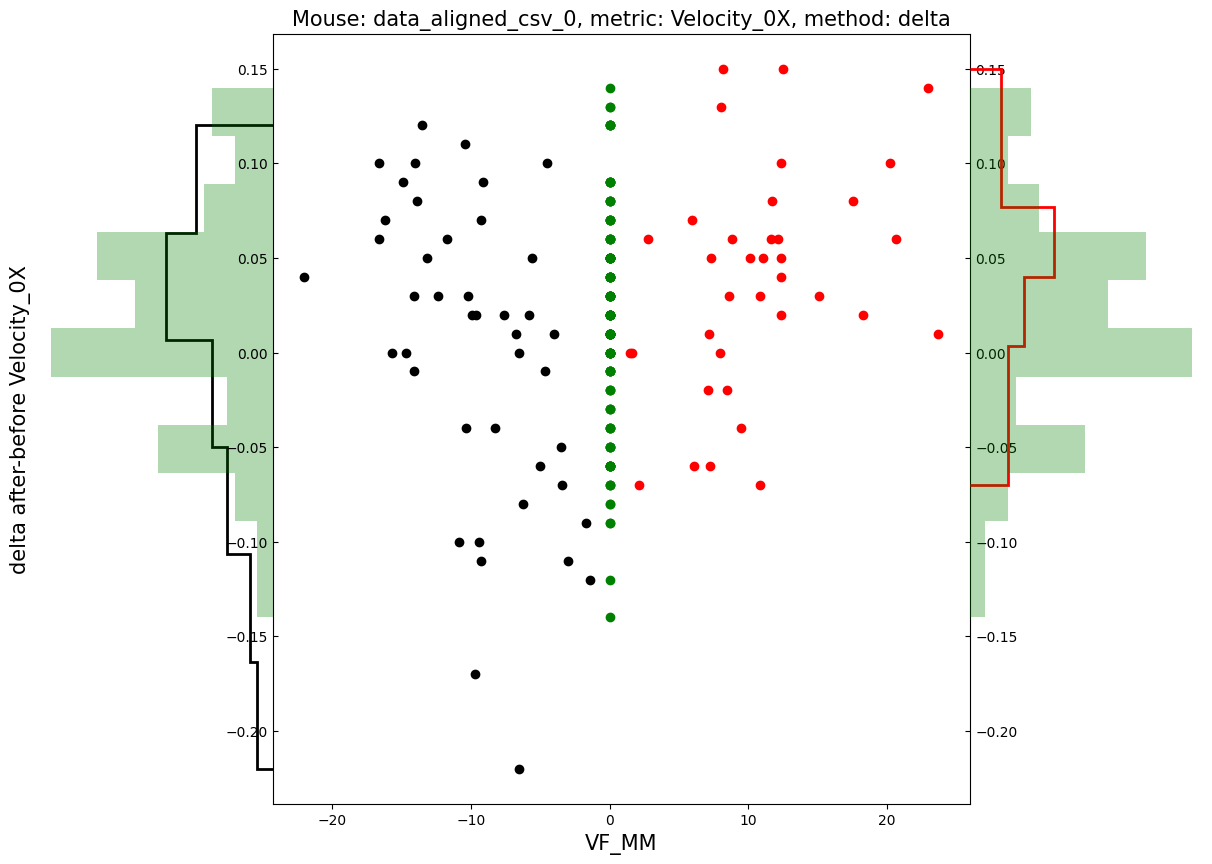

In [153]:
# B6J2718 : 
# PC office 
# processed_data_path_2xVF : data_aligned_csv_4
# processed_data_path_0xVF : data_aligned_csv_3

# PC Arthur
# processed_data_path_2xVF : data_aligned_csv_0
# processed_data_path_0xVF : data_aligned_csv_0

def fig_1(param_to_analyse, mouse, method):
    values_2VF, values_noMM, values_0VF = [], [], []
    values_motor_2VF, values_motor_0VF, values_motor_noMM = [], [], []

    if method.casefold() == 'ratio':
        for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
            values_2VF.append(dict_ratios_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_ratios_MM['processed_data_path_0xVF'][mouse])):
            values_0VF.append(dict_ratios_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_ratios_no_MM['processed_data_path_0xVF'][mouse])):
            values_noMM.append(dict_ratios_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        for i in range(len(dict_ratios_no_MM['processed_data_path_2xVF'][mouse])):
            values_noMM.append(dict_ratios_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

    elif method.casefold() == 'delta':
        for i in range(len(dict_delta_MM['processed_data_path_2xVF'][mouse])):
            values_2VF.append(dict_delta_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_delta_MM['processed_data_path_0xVF'][mouse])):
            values_0VF.append(dict_delta_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_delta_no_MM['processed_data_path_0xVF'][mouse])):
            values_noMM.append(dict_delta_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        for i in range(len(dict_delta_no_MM['processed_data_path_2xVF'][mouse])):
            values_noMM.append(dict_delta_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

    else :
        print('Method must be "ratio" or "delta".')
        return
        
    for i in range(len(dict_ratios_MM['processed_data_path_0xVF'][mouse])):
        values_motor_0VF.append(-1*(dict_ratios_MM['processed_data_path_0xVF'][mouse]['Motor_Velocity'][i]))
    for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
        values_motor_2VF.append(dict_ratios_MM['processed_data_path_2xVF'][mouse]['Motor_Velocity'][i])
    for _ in range(len(values_noMM)):
        values_motor_noMM.append(0)


    fig, (ax_left, ax_main, ax_right) = plt.subplots(1, 3,figsize=(15, 10), sharey=True, width_ratios=[1,3,1])
    fig.subplots_adjust(wspace=0)
    # Points
    ax_main.plot(values_motor_0VF, values_0VF, marker='o', color = 'black', linestyle='None')
    ax_main.plot(values_motor_2VF, values_2VF, marker='o', color = 'red', linestyle='None')
    ax_main.plot(values_motor_noMM, values_noMM, marker='o', color = 'green', linestyle='None')
    ax_main.set_title(f'Mouse: {mouse}, metric: {param_to_analyse}, method: {method}', size=15)

    ax_main.set_xlabel('VF_MM', size=15)
    if method.casefold() == 'delta':
        ax_main.set_ylabel(f'{method} after-before {param_to_analyse}', size=15, labelpad=140)
    elif method.casefold() == 'ratio':
        ax_main.set_ylabel(f'{method} (after-before) / before {param_to_analyse}', size=15, labelpad=140)

    ax_main.tick_params(axis='y', which='both', direction='in', left=True, right=True, labelleft=True, labelright=True)

    def calculate_bins(values):
        # q1 = np.percentile(values, 25)
        # q3 = np.percentile(values, 75)
        # iqr = q3 - q1
        # bins = int((max(values) - min(values)) / (2 * iqr / (len(values) ** (1/3))))
        bins = int(np.sqrt(len(values)))
        # print(f"Calculated number of bins: {bins}")
        return bins

    # Histo
    counts_0VF, bins_0VF = np.histogram(values_0VF, bins = calculate_bins(values_0VF))
    counts_2VF, bins_2VF = np.histogram(values_2VF, bins = calculate_bins(values_2VF))
    counts_noMM, bins_noMM = np.histogram(values_noMM, bins = calculate_bins(values_noMM))

    ax_left.stairs(-counts_0VF, bins_0VF, orientation = 'horizontal', color='black', linewidth=2)
    ax_left.stairs(-counts_noMM, bins_noMM, orientation = 'horizontal', color='green', fill=True, alpha=0.3)
    ax_left.axis('off')

    ax_right.stairs(counts_2VF, bins_2VF, orientation = 'horizontal', color='red', linewidth=2)
    ax_right.stairs(counts_noMM, bins_noMM, orientation = 'horizontal', color='green', fill=True, alpha=0.3)
    ax_right.axis('off')

    plt.show()

fig_1(param_to_analyse = 'Velocity_0X', mouse = 'data_aligned_csv_0', method = 'delta')
